# Praktikum Pengolahan Citra - Konvolusi, Korelasi, dan Low Pass Filter

**Tujuan:** Implementasi korelasi, konvolusi, dan low pass filter pada citra dengan penjelasan setiap langkah.

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import correlate, convolve

plt.rcParams['figure.figsize'] = (15, 10)

print("Library loaded")

Library loaded


## 1. Load Image

In [24]:
image_bgr = cv2.imread('citra-objek.jpg')
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Image shape: {image_rgb.shape}")
print(f"Grayscale shape: {image_gray.shape}")

Image shape: (400, 400, 3)
Grayscale shape: (400, 400)


Menampilkan citra asli RGB dan grayscale

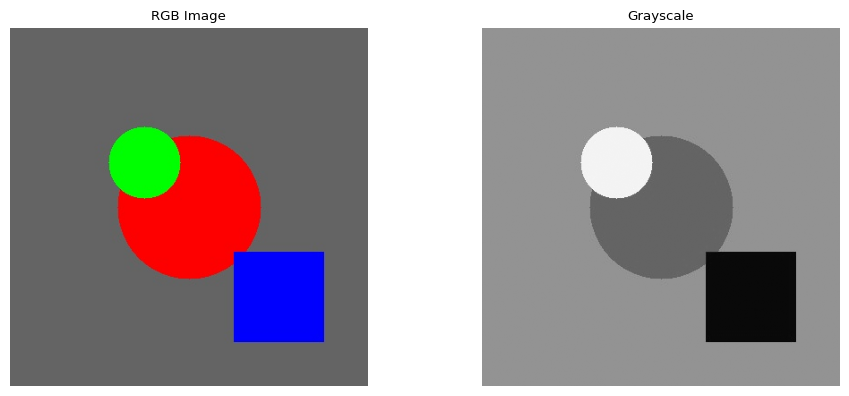

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(image_rgb)
ax[0].set_title('RGB Image')
ax[0].axis('off')
ax[1].imshow(image_gray, cmap='gray')
ax[1].set_title('Grayscale')
ax[1].axis('off')
plt.tight_layout()
plt.show()

## 2. Define Kernels

In [26]:
# Kernel Sobel
kernel_sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
kernel_sy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

# Low pass filter kernels
kernel_avg = np.ones((3, 3), dtype=np.float32) / 9
kernel_gauss = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16

# Laplacian
kernel_lap = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float32)

print("Kernels created")

Kernels created


Visualisasi kernel yang digunakan

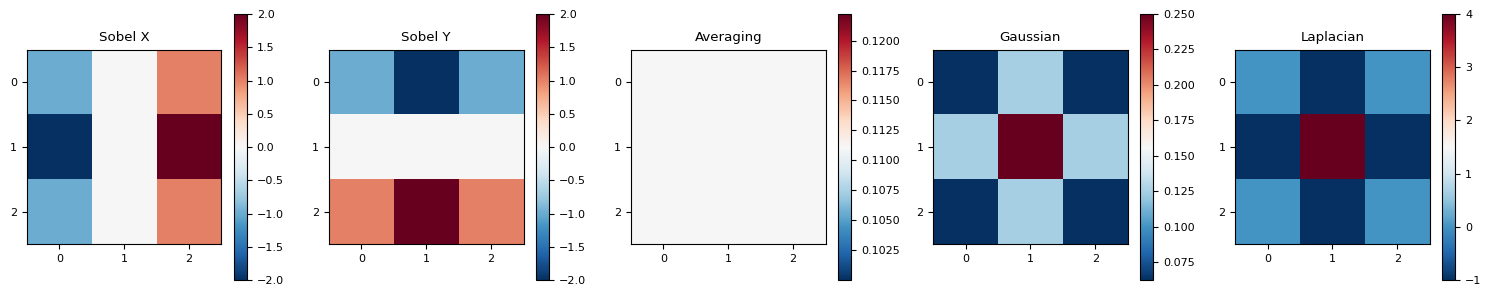

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
kernels_list = [
    (kernel_sx, 'Sobel X'),
    (kernel_sy, 'Sobel Y'),
    (kernel_avg, 'Averaging'),
    (kernel_gauss, 'Gaussian'),
    (kernel_lap, 'Laplacian')
]

for idx, (kernel, title) in enumerate(kernels_list):
    im = axes[idx].imshow(kernel, cmap='RdBu_r')
    axes[idx].set_title(title)
    axes[idx].set_xticks([0, 1, 2])
    axes[idx].set_yticks([0, 1, 2])
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

## PRAKTIKUM – BAGIAN 1: KONVOLUSI

Correlation done
Sobel X range: [-303, 289]
Sobel Y range: [-299, 291]


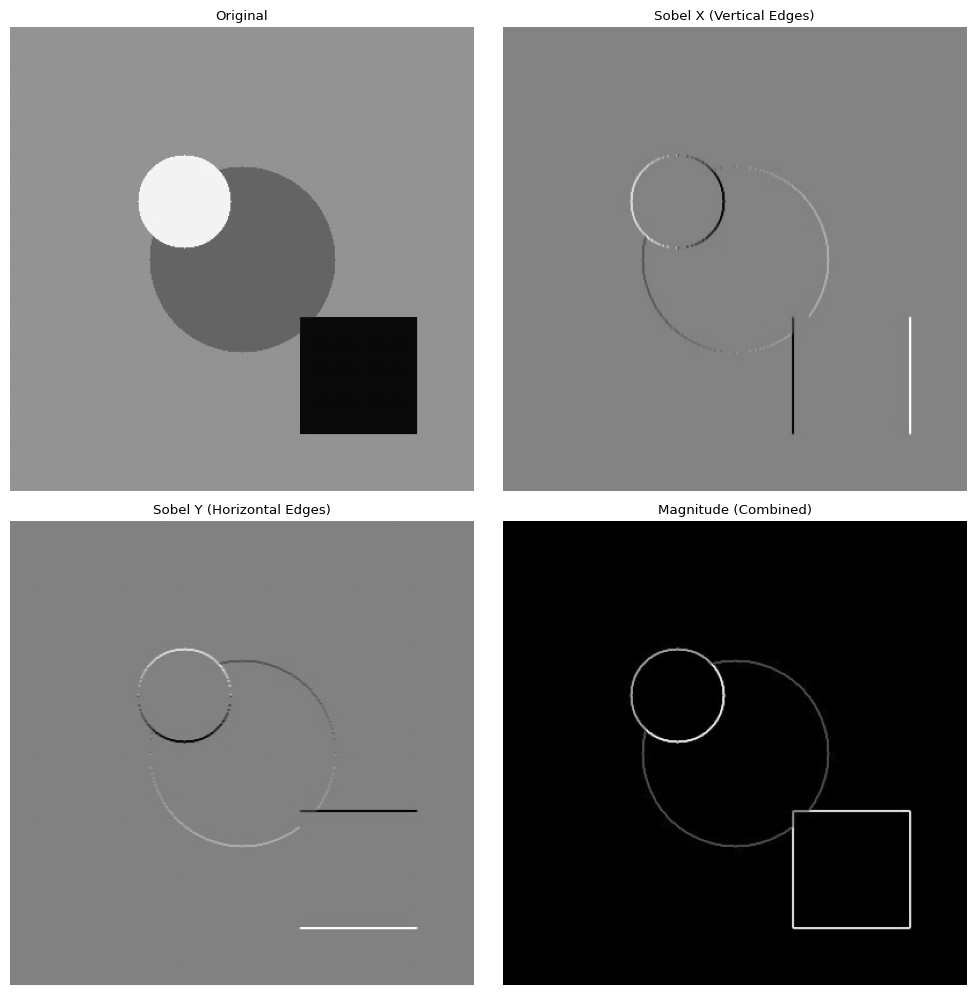

In [ ]:
# Konvolusi menggunakan Sobel
conv_sx = convolve(image_gray.astype(np.float32), kernel_sx, mode='reflect')
conv_sy = convolve(image_gray.astype(np.float32), kernel_sy, mode='reflect')

# Magnitude
conv_mag = np.sqrt(conv_sx**2 + conv_sy**2)
conv_mag_norm = (conv_mag / conv_mag.max() * 255).astype(np.uint8)

# Laplacian
conv_lap = convolve(image_gray.astype(np.float32), kernel_lap, mode='reflect')
conv_lap_norm = np.clip((conv_lap - conv_lap.min()) / (conv_lap.max() - conv_lap.min()) * 255, 0, 255).astype(np.uint8)

print("Convolution done")
print(f"Sobel X range: [{conv_sx.min():.0f}, {conv_sx.max():.0f}]")
print(f"Laplacian range: [{conv_lap.min():.0f}, {conv_lap.max():.0f}]")

# Visualisasi hasil konvolusi
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

ax[0, 0].imshow(image_gray, cmap='gray')
ax[0, 0].set_title('Original')
ax[0, 0].axis('off')

ax[0, 1].imshow(conv_mag_norm, cmap='gray')
ax[0, 1].set_title('Sobel (Combined)')
ax[0, 1].axis('off')

ax[1, 0].imshow(conv_lap_norm, cmap='gray')
ax[1, 0].set_title('Laplacian Edge Detection')
ax[1, 0].axis('off')

diff = np.abs(corr_mag_norm.astype(np.float32) - conv_mag_norm.astype(np.float32))
ax[1, 1].imshow(diff, cmap='hot')

ax[1, 1].set_title('Correlation vs Convolution Diff')plt.show()

ax[1, 1].axis('off')plt.tight_layout()


## PRAKTIKUM – BAGIAN 2: KORELASI

Convolution done
Sobel X range: [-289, 303]
Laplacian range: [-183, 212]


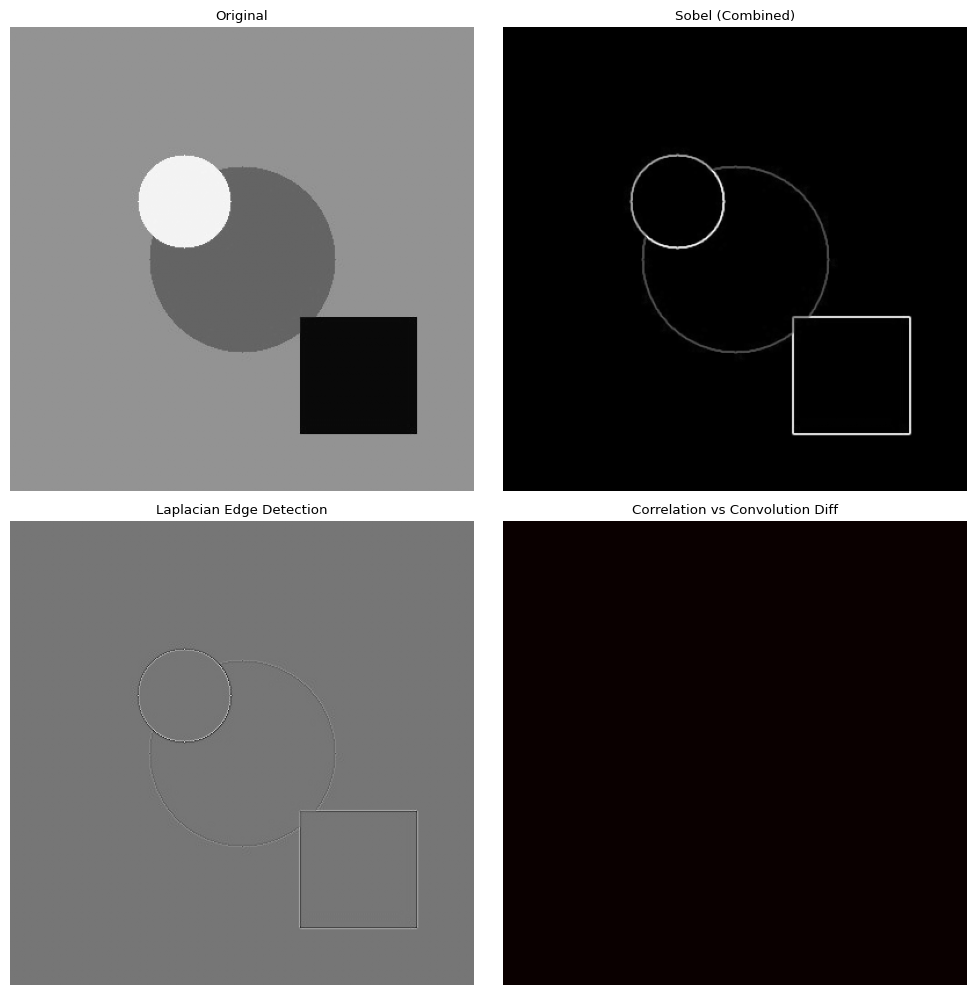

In [ ]:
# Korelasi menggunakan Sobel
corr_sx = correlate(image_gray.astype(np.float32), kernel_sx, mode='reflect')
corr_sy = correlate(image_gray.astype(np.float32), kernel_sy, mode='reflect')

# Magnitude
corr_mag = np.sqrt(corr_sx**2 + corr_sy**2)
corr_mag_norm = (corr_mag / corr_mag.max() * 255).astype(np.uint8)

print("Correlation done")
print(f"Sobel X range: [{corr_sx.min():.0f}, {corr_sx.max():.0f}]")
print(f"Sobel Y range: [{corr_sy.min():.0f}, {corr_sy.max():.0f}]")

# Visualisasi hasil korelasi
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

ax[0, 0].imshow(image_gray, cmap='gray')
ax[0, 0].set_title('Original')
ax[0, 0].axis('off')

ax[0, 1].imshow(corr_sx, cmap='gray')
ax[0, 1].set_title('Sobel X (Vertical Edges)')
ax[0, 1].axis('off')

ax[1, 0].imshow(corr_sy, cmap='gray')
ax[1, 0].set_title('Sobel Y (Horizontal Edges)')
ax[1, 0].axis('off')

ax[1, 1].imshow(corr_mag_norm, cmap='gray')
ax[1, 1].set_title('Magnitude (Combined)')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

## PRAKTIKUM – BAGIAN 3: SPATIAL FILTERING LOW PASS FILTER

Low pass filtering done
Averaging - mean: 94.48, std: 20.53
Gaussian - mean: 94.48, std: 20.57


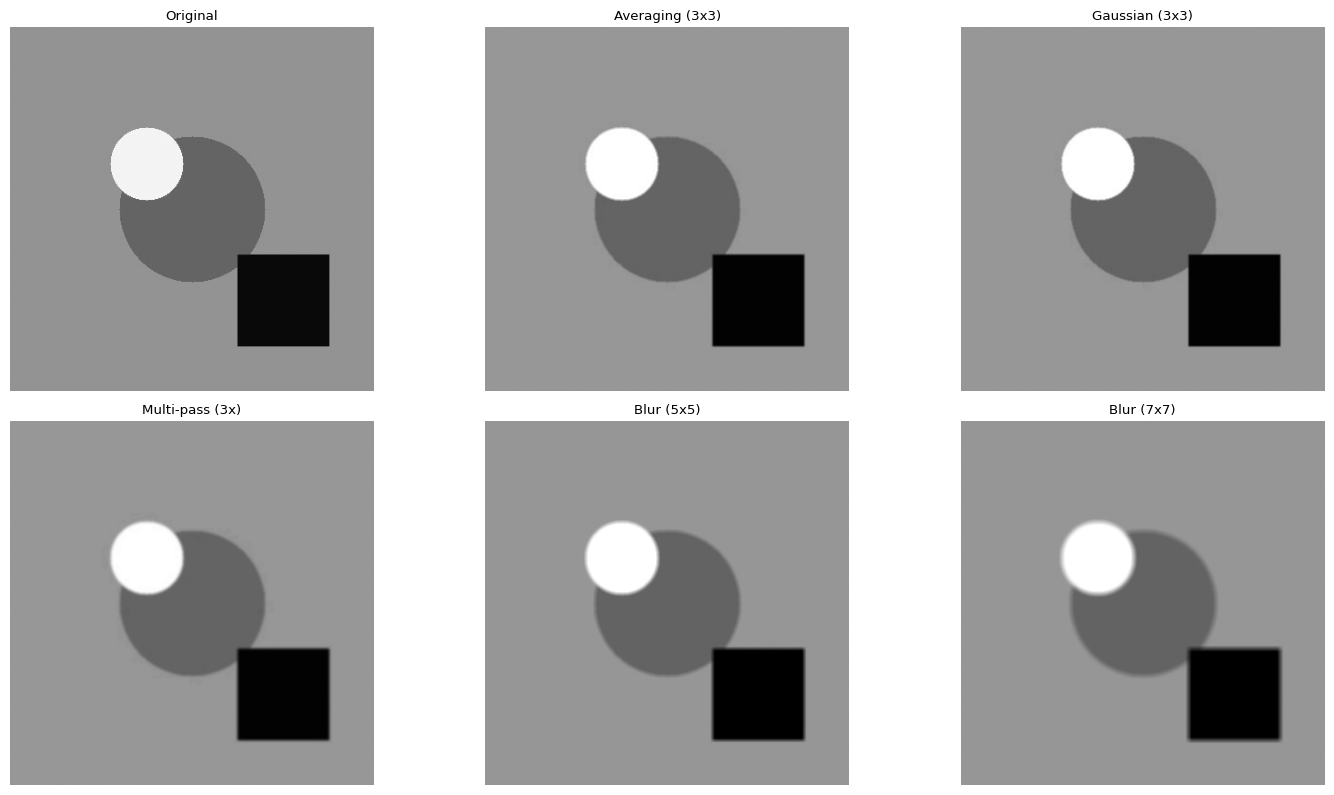

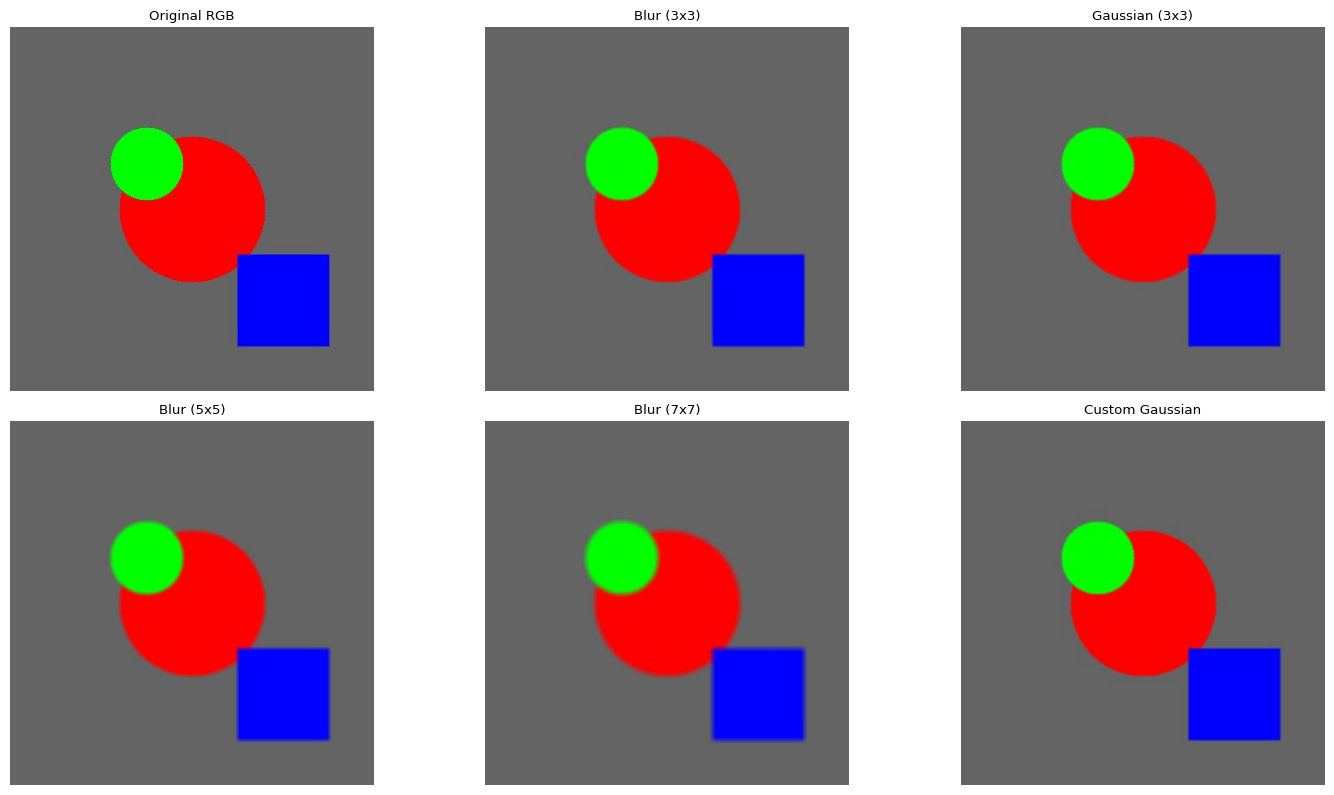

RGB filtering done


In [41]:
# Low pass filtering on grayscale
lpf_avg = convolve(image_gray.astype(np.float32), kernel_avg, mode='reflect')
lpf_avg = np.clip(lpf_avg, 0, 255).astype(np.uint8)

lpf_gauss = convolve(image_gray.astype(np.float32), kernel_gauss, mode='reflect')
lpf_gauss = np.clip(lpf_gauss, 0, 255).astype(np.uint8)

# Multiple passes
lpf_multi = image_gray.astype(np.float32)
for _ in range(3):
    lpf_multi = convolve(lpf_multi, kernel_avg, mode='reflect')
lpf_multi = np.clip(lpf_multi, 0, 255).astype(np.uint8)

# Using OpenCV
lpf_cv_3 = cv2.blur(image_gray, (3, 3))
lpf_cv_5 = cv2.blur(image_gray, (5, 5))
lpf_cv_7 = cv2.blur(image_gray, (7, 7))

print("Low pass filtering done")
print(f"Averaging - mean: {lpf_avg.mean():.2f}, std: {lpf_avg.std():.2f}")
print(f"Gaussian - mean: {lpf_gauss.mean():.2f}, std: {lpf_gauss.std():.2f}")

# Low pass on RGB
lpf_rgb_3 = cv2.blur(image_rgb, (3, 3))
lpf_rgb_5 = cv2.blur(image_rgb, (5, 5))
lpf_rgb_7 = cv2.blur(image_rgb, (7, 7))
lpf_rgb_gauss = cv2.GaussianBlur(image_rgb, (3, 3), 1.0)

# Manual Gaussian per channel
r, g, b = image_rgb[:,:,0], image_rgb[:,:,1], image_rgb[:,:,2]
r_filt = np.clip(convolve(r.astype(np.float32), kernel_gauss, mode='reflect'), 0, 255).astype(np.uint8)
g_filt = np.clip(convolve(g.astype(np.float32), kernel_gauss, mode='reflect'), 0, 255).astype(np.uint8)
b_filt = np.clip(convolve(b.astype(np.float32), kernel_gauss, mode='reflect'), 0, 255).astype(np.uint8)
lpf_rgb_custom = np.stack([r_filt, g_filt, b_filt], axis=2)

# Grayscale visualization
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

ax[0, 0].imshow(image_gray, cmap='gray')
ax[0, 0].set_title('Original')
ax[0, 0].axis('off')

ax[0, 1].imshow(lpf_avg, cmap='gray')
ax[0, 1].set_title('Averaging (3x3)')
ax[0, 1].axis('off')

ax[0, 2].imshow(lpf_gauss, cmap='gray')
ax[0, 2].set_title('Gaussian (3x3)')
ax[0, 2].axis('off')

ax[1, 0].imshow(lpf_multi, cmap='gray')
ax[1, 0].set_title('Multi-pass (3x)')
ax[1, 0].axis('off')

ax[1, 1].imshow(lpf_cv_5, cmap='gray')
ax[1, 1].set_title('Blur (5x5)')
ax[1, 1].axis('off')

ax[1, 2].imshow(lpf_cv_7, cmap='gray')
ax[1, 2].set_title('Blur (7x7)')
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()

# RGB visualization
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

ax[0, 0].imshow(image_rgb)
ax[0, 0].set_title('Original RGB')
ax[0, 0].axis('off')

ax[0, 1].imshow(lpf_rgb_3)
ax[0, 1].set_title('Blur (3x3)')
ax[0, 1].axis('off')

ax[0, 2].imshow(lpf_rgb_gauss)
ax[0, 2].set_title('Gaussian (3x3)')
ax[0, 2].axis('off')

ax[1, 0].imshow(lpf_rgb_5)
ax[1, 0].set_title('Blur (5x5)')
ax[1, 0].axis('off')

ax[1, 1].imshow(lpf_rgb_7)
ax[1, 1].set_title('Blur (7x7)')
ax[1, 1].axis('off')

ax[1, 2].imshow(lpf_rgb_custom)
ax[1, 2].set_title('Custom Gaussian')
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("RGB filtering done")

Analysis and comparison

In [36]:
# Metrics comparison
metrics = {
    'Original': (image_gray.mean(), image_gray.std()),
    'Averaging': (lpf_avg.mean(), lpf_avg.std()),
    'Gaussian': (lpf_gauss.mean(), lpf_gauss.std()),
    'Blur 5x5': (lpf_cv_5.mean(), lpf_cv_5.std()),
    'Blur 7x7': (lpf_cv_7.mean(), lpf_cv_7.std())
}

print("\nImage Metrics (Mean, Std Dev):")
print("-" * 50)
for name, (mean, std) in metrics.items():
    print(f"{name:15} -> Mean: {mean:6.2f}, Std: {std:6.2f}")

# PSNR calculation
def calc_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32))**2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255 / np.sqrt(mse))

print("\nPSNR (dB):")
print("-" * 50)
print(f"Averaging: {calc_psnr(image_gray, lpf_avg):.2f} dB")
print(f"Gaussian:  {calc_psnr(image_gray, lpf_gauss):.2f} dB")
print(f"Blur 5x5:  {calc_psnr(image_gray, lpf_cv_5):.2f} dB")


Image Metrics (Mean, Std Dev):
--------------------------------------------------
Original        -> Mean:  94.50, Std:  20.74
Averaging       -> Mean:  94.48, Std:  20.53
Gaussian        -> Mean:  94.48, Std:  20.57
Blur 5x5        -> Mean:  94.50, Std:  20.37
Blur 7x7        -> Mean:  94.50, Std:  20.20

PSNR (dB):
--------------------------------------------------
Averaging: 41.70 dB
Gaussian:  43.88 dB
Blur 5x5:  39.24 dB


Histogram comparison

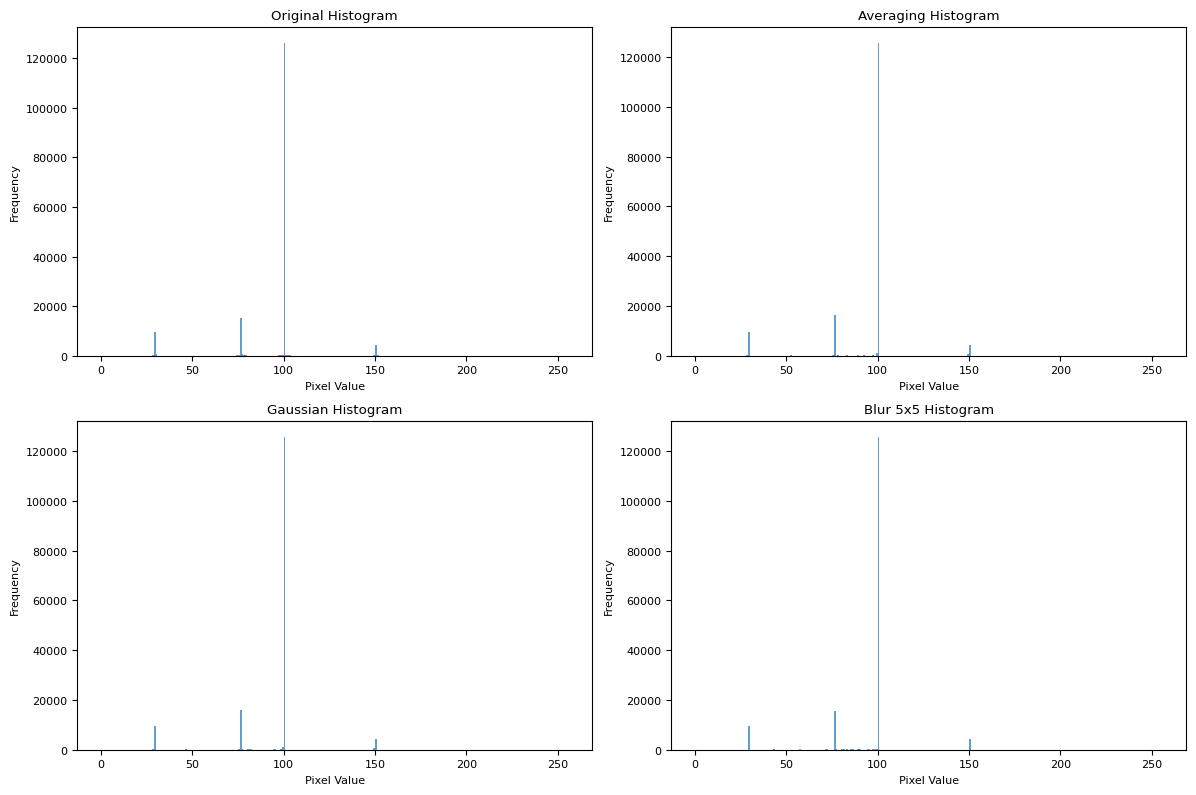

In [37]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].hist(image_gray.flatten(), bins=256, range=(0, 256), alpha=0.7)
ax[0, 0].set_title('Original Histogram')

ax[0, 1].hist(lpf_avg.flatten(), bins=256, range=(0, 256), alpha=0.7)
ax[0, 1].set_title('Averaging Histogram')

ax[1, 0].hist(lpf_gauss.flatten(), bins=256, range=(0, 256), alpha=0.7)
ax[1, 0].set_title('Gaussian Histogram')

ax[1, 1].hist(lpf_cv_5.flatten(), bins=256, range=(0, 256), alpha=0.7)
ax[1, 1].set_title('Blur 5x5 Histogram')

for axi in ax.flat:
    axi.set_xlabel('Pixel Value')
    axi.set_ylabel('Frequency')

plt.tight_layout()
plt.show()